# Notebook 03: Inflation Study

## Objective

This notebook investigates the inflation requirements for three ensemble-based data assimilation methods applied to the Lorenz-96 system:

- Sequential Stochastic EnKF (Seq-EnKF)
- 4D Stochastic EnKF (4D-EnKF)
- QPCA Ensemble Data Consistency Filter (QPCA-EnDCF)

**Research Question:** Does QPCA-EnDCF require less inflation due to its implicit spectral regularization?

**Hypothesis:** QPCA-EnDCF should require minimal inflation (close to 1.0) compared to stochastic EnKF variants because:

1. It avoids observation perturbation noise
2. PCA-based filtering provides natural regularization
3. Whitened residual space filtering suppresses spurious modes

We test:

- **Multiplicative inflation factors:** [1.0, 1.05, 1.1, 1.15, 1.2, 1.25]
- **Additive inflation levels:** [0.0, 0.01, 0.05, 0.1, 0.15, 0.2]
- **Ensemble sizes:** [5, 10, 25] (small ensembles where inflation is most critical)


## Setup


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from numpy.linalg import cholesky
import sys
import pickle
import os
from pathlib import Path
import itertools
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")

# Add src to path
if "../" not in sys.path:
    sys.path.insert(0, os.path.abspath(".."))

from src.models.lorenz96 import integrate_model, rk4_step, l96_rhs
from src.filters.seq_enkf import StochasticEnKF
from src.filters.enkf_4d import StochasticEnKF4D
from src.filters.qpca_endcf import QPCAEnDCF
from src.utils.observations import build_obs_operator
from src.utils.metrics import rmse, rel_data_misfit
from src.utils.linalg import sym_posdef_inverse

from src.config import PAPER_FIGURES_DIR, PAPER_DATA_DIR, PAPERUQ_FIGURES_DIR

# Random seed for reproducibility
MASTER_SEED = 42
np.random.seed(MASTER_SEED)

plt.style.use("publication_style.mplstyle")

Lorenz-96 model utilities implemented using src/models/lorenz96.py
Observation utilities implemented using src/utils/observations.py


/Users/rylanspence/mambaforge/envs/endcf_pca/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration Parameters

Following the research plan baseline configuration with modifications for inflation study.


In [27]:
# Lorenz-96 system parameters
N_STATE = 40  # State dimension
OBSERVE_EVERY = 2  # Observe every 2nd state (m=20)
F_PARAM = 8.0  # Forcing parameter (chaotic regime)
DT_MODEL = 0.01  # Integration time step
STEPS_PER_OBS = 10  # Steps between observations (Tobs = 0.1)

# Assimilation parameters
WINDOW_LEN = 5  # Observations per 4D window
N_WINDOWS = 50  # Number of assimilation windows
OBS_NOISE_STD = 1.5  # Observation noise standard deviation
QPCA_K = 1  # Number of PCA modes for QPCA-EnDCF

# Inflation study parameters
MULT_INFLATION_FACTORS = [1.0, 1.05, 1.1, 1.15, 1.2, 1.25]
ADD_INFLATION_LEVELS = [0, 0.01, 0.05, 0.1, 0.15, 0.2]
ENSEMBLE_SIZES = [5, 10, 25, 50]
N_SEEDS = 3  # Number of random seeds per configuration

# Seeds for reproducibility
SEEDS = [42, 123, 456]

print(f"Total observations per run: {N_WINDOWS * WINDOW_LEN}")
print(f"Observation dimension: {N_STATE // OBSERVE_EVERY}")
print(
    f"Number of experiments: {len(MULT_INFLATION_FACTORS) * len(ENSEMBLE_SIZES) * N_SEEDS} (multiplicative)"
)
print(
    f"Number of experiments: {len(ADD_INFLATION_LEVELS) * len(ENSEMBLE_SIZES) * N_SEEDS} (additive)"
)

Total observations per run: 250
Observation dimension: 20
Number of experiments: 72 (multiplicative)
Number of experiments: 72 (additive)


## Experiments

### Helper Functions


In [3]:
def apply_multiplicative_inflation(X, inflation_factor):
    """
    Apply multiplicative covariance inflation to ensemble.

    X' = mean + inflation_factor * (X - mean)

    Parameters
    ----------
    X : ndarray, shape (n, N)
        Ensemble matrix (columns = particles)
    inflation_factor : float
        Multiplicative inflation factor (>= 1.0)

    Returns
    -------
    X_inflated : ndarray, shape (n, N)
        Inflated ensemble
    """
    if inflation_factor == 1.0:
        return X

    x_mean = X.mean(axis=1, keepdims=True)
    X_anom = X - x_mean
    return x_mean + inflation_factor * X_anom


def apply_additive_inflation(X, inflation_std, rng):
    """
    Apply additive inflation by adding random noise to ensemble.

    X' = X + σ_add * ξ, where ξ ~ N(0, I)

    Parameters
    ----------
    X : ndarray, shape (n, N)
        Ensemble matrix (columns = particles)
    inflation_std : float
        Standard deviation of additive noise
    rng : numpy.random.Generator
        Random number generator

    Returns
    -------
    X_inflated : ndarray, shape (n, N)
        Inflated ensemble
    """
    if inflation_std == 0.0:
        return X

    n, N = X.shape
    noise = inflation_std * rng.standard_normal(size=(n, N))
    return X + noise


def run_inflation_experiment(
    seed,
    n=40,
    observe_every=2,
    F=8.0,
    dt_model=0.01,
    steps_per_obs=10,
    window_len=5,
    n_windows=50,
    N_ens=10,
    obs_noise_std=1.5,
    spinup_steps=0,
    qpca_k=1,
    inflation_type="multiplicative",  # "multiplicative" or "additive"
    inflation_value=1.0,  # multiplicative factor or additive std
):
    """
    Run a single inflation experiment for all three filters.

    Parameters
    ----------
    seed : int
        Random seed
    n : int
        State dimension
    observe_every : int
        Observe every k-th state variable
    F : float
        Lorenz-96 forcing parameter
    dt_model : float
        Integration time step
    steps_per_obs : int
        Number of integration steps between observations
    window_len : int
        Number of observation times per assimilation window
    n_windows : int
        Number of assimilation windows
    N_ens : int
        Ensemble size
    obs_noise_std : float
        Observation noise standard deviation
    spinup_steps : int
        Number of spinup steps for truth trajectory
    qpca_k : int
        Number of PCA modes to retain in QPCA-EnDCF
    inflation_type : str
        "multiplicative" or "additive"
    inflation_value : float
        Inflation parameter value

    Returns
    -------
    results : dict
        Dictionary containing RMSE and misfit arrays for each filter
    """
    rng = np.random.default_rng(seed)

    # Observation operator and noise
    H, obs_idx = build_obs_operator(n, observe_every)
    m = H.shape[0]
    R = (obs_noise_std**2) * np.eye(m)

    # Truth spinup and full run
    x0_true = rng.normal(0.0, 1.0, size=n)
    x_spin = integrate_model(x0_true, dt_model, spinup_steps, F=F)[-1]

    # Total observations
    K_total = n_windows * window_len
    steps_total = K_total * steps_per_obs
    truth_traj = integrate_model(x_spin, dt_model, steps_total, F=F)

    # Observation times and noisy obs
    obs_steps = np.arange(steps_per_obs, steps_total + 1, steps_per_obs)
    true_at_obs = truth_traj[obs_steps]

    Z = np.empty((K_total, m))
    for k in range(K_total):
        z_clean = H @ true_at_obs[k]
        Z[k] = z_clean + obs_noise_std * rng.standard_normal(m)

    # Initial ensemble
    X0 = (true_at_obs[0] + 0.5 * rng.standard_normal(n))[
        :, None
    ] + 0.5 * rng.standard_normal(size=(n, N_ens))

    # Filters
    enkf4d = StochasticEnKF4D(H, R, window_len=window_len)
    qpca4d = QPCAEnDCF(H, R, window_len=window_len, k=qpca_k, stabilize=True)
    seq_enkf = StochasticEnKF(H, R, stabilize=False)

    # Storage
    rmse_enkf4d, rmse_qpca4d, rmse_seq = [], [], []
    misfit_enkf4d, misfit_qpca4d, misfit_seq = [], [], []

    # Working ensembles
    X_enkf4d = X0.copy()
    X_qpca4d = X0.copy()
    X_seq = X0.copy()

    # For misfit metric
    R_inv_sqrt = cholesky(sym_posdef_inverse(R))

    # Iterate over windows
    obs_ptr = 0
    for w in range(n_windows):
        # Paths for 4D filters
        X_path_enkf4d = []
        X_path_qpca4d = []

        for ell in range(window_len):
            # Propagate all three ensembles
            for _ in range(steps_per_obs):
                for j in range(N_ens):
                    X_enkf4d[:, j] = rk4_step(l96_rhs, X_enkf4d[:, j], dt_model, F=F)
                    X_qpca4d[:, j] = rk4_step(l96_rhs, X_qpca4d[:, j], dt_model, F=F)
                    X_seq[:, j] = rk4_step(l96_rhs, X_seq[:, j], dt_model, F=F)

            # Store for 4D filters
            X_path_enkf4d.append(X_enkf4d.copy())
            X_path_qpca4d.append(X_qpca4d.copy())

            # Sequential EnKF update
            z_k = Z[obs_ptr + ell]
            X_seq = seq_enkf.update(X_seq, z_k, rng=rng)

            # Apply inflation after update for sequential
            if inflation_type == "multiplicative":
                X_seq = apply_multiplicative_inflation(X_seq, inflation_value)
            elif inflation_type == "additive":
                X_seq = apply_additive_inflation(X_seq, inflation_value, rng)

        # Stack observations for this window
        z_block = Z[obs_ptr : obs_ptr + window_len]
        z_stack = z_block.reshape(-1)
        obs_ptr += window_len

        # 4D Stochastic EnKF joint update
        X_enkf4d = enkf4d.update(X_path_enkf4d, z_stack)

        # Apply inflation after update
        if inflation_type == "multiplicative":
            X_enkf4d = apply_multiplicative_inflation(X_enkf4d, inflation_value)
        elif inflation_type == "additive":
            X_enkf4d = apply_additive_inflation(X_enkf4d, inflation_value, rng)

        xmean_enkf4d = X_enkf4d.mean(axis=1)

        # 4D QPCA–EnDCF joint update
        X_qpca4d = qpca4d.update(X_path_qpca4d, z_stack)

        # Apply inflation after update
        if inflation_type == "multiplicative":
            X_qpca4d = apply_multiplicative_inflation(X_qpca4d, inflation_value)
        elif inflation_type == "additive":
            X_qpca4d = apply_additive_inflation(X_qpca4d, inflation_value, rng)

        xmean_qpca4d = X_qpca4d.mean(axis=1)

        # Sequential EnKF mean
        xmean_seq = X_seq.mean(axis=1)

        # Window-end truth and observation
        x_true_end = true_at_obs[obs_ptr - 1]
        z_end = Z[obs_ptr - 1]

        # Metrics at window end
        rmse_enkf4d.append(rmse(xmean_enkf4d, x_true_end))
        rmse_qpca4d.append(rmse(xmean_qpca4d, x_true_end))
        rmse_seq.append(rmse(xmean_seq, x_true_end))

        misfit_enkf4d.append(rel_data_misfit(z_end, H @ xmean_enkf4d, R_inv_sqrt))
        misfit_qpca4d.append(rel_data_misfit(z_end, H @ xmean_qpca4d, R_inv_sqrt))
        misfit_seq.append(rel_data_misfit(z_end, H @ xmean_seq, R_inv_sqrt))

    results = {
        "rmse_enkf4d": np.array(rmse_enkf4d),
        "rmse_qpca4d": np.array(rmse_qpca4d),
        "rmse_seq": np.array(rmse_seq),
        "misfit_enkf4d": np.array(misfit_enkf4d),
        "misfit_qpca4d": np.array(misfit_qpca4d),
        "misfit_seq": np.array(misfit_seq),
    }
    return results


print("Helper functions defined!")

Helper functions defined!


### Run Multiplicative Inflation Experiments


In [4]:
# Storage for results: mult_results[filter_name][N_ens][inflation_factor][seed] = results_dict
mult_results = {
    "seq": {
        N_ens: {infl: {} for infl in MULT_INFLATION_FACTORS} for N_ens in ENSEMBLE_SIZES
    },
    "enkf4d": {
        N_ens: {infl: {} for infl in MULT_INFLATION_FACTORS} for N_ens in ENSEMBLE_SIZES
    },
    "qpca4d": {
        N_ens: {infl: {} for infl in MULT_INFLATION_FACTORS} for N_ens in ENSEMBLE_SIZES
    },
}

# Run experiments
total_experiments = len(ENSEMBLE_SIZES) * len(MULT_INFLATION_FACTORS) * len(SEEDS)
pbar = tqdm(total=total_experiments, desc="Multiplicative Inflation Experiments")

for N_ens in ENSEMBLE_SIZES:
    for inflation_factor in MULT_INFLATION_FACTORS:
        for seed in SEEDS:
            results = run_inflation_experiment(
                seed=seed,
                n=N_STATE,
                observe_every=OBSERVE_EVERY,
                F=F_PARAM,
                dt_model=DT_MODEL,
                steps_per_obs=STEPS_PER_OBS,
                window_len=WINDOW_LEN,
                n_windows=N_WINDOWS,
                N_ens=N_ens,
                obs_noise_std=OBS_NOISE_STD,
                qpca_k=QPCA_K,
                inflation_type="multiplicative",
                inflation_value=inflation_factor,
            )

            mult_results["seq"][N_ens][inflation_factor][seed] = results["rmse_seq"]
            mult_results["enkf4d"][N_ens][inflation_factor][seed] = results[
                "rmse_enkf4d"
            ]
            mult_results["qpca4d"][N_ens][inflation_factor][seed] = results[
                "rmse_qpca4d"
            ]

            pbar.update(1)

pbar.close()
print("\n✓ Multiplicative inflation experiments complete!")

Multiplicative Inflation Experiments: 100%|██████████| 72/72 [22:23<00:00, 18.65s/it]


✓ Multiplicative inflation experiments complete!


### Run Additive Inflation Experiments


In [5]:
# Storage for results: add_results[filter_name][N_ens][inflation_level][seed] = results_dict
add_results = {
    "seq": {
        N_ens: {infl: {} for infl in ADD_INFLATION_LEVELS} for N_ens in ENSEMBLE_SIZES
    },
    "enkf4d": {
        N_ens: {infl: {} for infl in ADD_INFLATION_LEVELS} for N_ens in ENSEMBLE_SIZES
    },
    "qpca4d": {
        N_ens: {infl: {} for infl in ADD_INFLATION_LEVELS} for N_ens in ENSEMBLE_SIZES
    },
}

# Run experiments
total_experiments = len(ENSEMBLE_SIZES) * len(ADD_INFLATION_LEVELS) * len(SEEDS)
pbar = tqdm(total=total_experiments, desc="Additive Inflation Experiments")

for N_ens in ENSEMBLE_SIZES:
    for inflation_level in ADD_INFLATION_LEVELS:
        for seed in SEEDS:
            results = run_inflation_experiment(
                seed=seed,
                n=N_STATE,
                observe_every=OBSERVE_EVERY,
                F=F_PARAM,
                dt_model=DT_MODEL,
                steps_per_obs=STEPS_PER_OBS,
                window_len=WINDOW_LEN,
                n_windows=N_WINDOWS,
                N_ens=N_ens,
                obs_noise_std=OBS_NOISE_STD,
                qpca_k=QPCA_K,
                inflation_type="additive",
                inflation_value=inflation_level,
            )

            add_results["seq"][N_ens][inflation_level][seed] = results["rmse_seq"]
            add_results["enkf4d"][N_ens][inflation_level][seed] = results["rmse_enkf4d"]
            add_results["qpca4d"][N_ens][inflation_level][seed] = results["rmse_qpca4d"]

            pbar.update(1)

pbar.close()
print("\n✓ Additive inflation experiments complete!")

Additive Inflation Experiments: 100%|██████████| 72/72 [21:50<00:00, 18.21s/it]


✓ Additive inflation experiments complete!


### Compute Summary Statistics


In [6]:
def compute_statistics(results_dict):
    """
    Compute mean and std of RMSE across seeds for each filter/ensemble_size/inflation combination.

    Parameters
    ----------
    results_dict : dict
        Nested dictionary with structure [filter][N_ens][inflation][seed] = rmse_array

    Returns
    -------
    stats : dict
        Dictionary with structure [filter][N_ens][inflation] = {"rmse_mean": float, "rmse_std": float}
    """
    stats = {}

    for filter_name in results_dict.keys():
        stats[filter_name] = {}

        for N_ens in results_dict[filter_name].keys():
            stats[filter_name][N_ens] = {}

            for inflation in results_dict[filter_name][N_ens].keys():
                # Collect RMSE across all seeds
                all_rmse = []
                for seed in results_dict[filter_name][N_ens][inflation].keys():
                    rmse_array = results_dict[filter_name][N_ens][inflation][seed]
                    # Mean RMSE over all windows for this seed
                    all_rmse.append(np.mean(rmse_array))

                # Statistics across seeds
                stats[filter_name][N_ens][inflation] = {
                    "rmse_mean": np.mean(all_rmse),
                    "rmse_std": np.std(all_rmse, ddof=1) if len(all_rmse) > 1 else 0.0,
                }

    return stats


# Compute statistics
mult_stats = compute_statistics(mult_results)
add_stats = compute_statistics(add_results)

# # save multiplicative stats

# with open(PAPER_DATA_DIR / "multiplicative_inflation_stats.pkl", "wb") as f:
#     pickle.dump(mult_stats, f)
# # save additive stats
# with open(PAPER_DATA_DIR / "additive_inflation_stats.pkl", "wb") as f:
#     pickle.dump(add_stats, f)

print("✓ Summary statistics computed!")

✓ Summary statistics computed!


## Publication-Quality Figures


In [16]:
# Professional color palette (colorblind-friendly)
# Using Wong (2011) color palette - Nature Methods recommended
CB_COLORS = {
    "seq": "#0173B2",  # Blue
    "enkf4d": "#DE8F05",  # Orange
    "qpca4d": "#029E73",  # Teal/Green
}

# Consistent marker styles
STYLES = {
    "seq": dict(
        marker="o", linestyle="-", markerfacecolor="white", markeredgecolor="#0173B2"
    ),
    "enkf4d": dict(
        marker="s", linestyle="-", markerfacecolor="white", markeredgecolor="#DE8F05"
    ),
    "qpca4d": dict(
        marker="^", linestyle="-", markerfacecolor="white", markeredgecolor="#029E73"
    ),
}

# Professional labels
LABELS = {
    "seq": "Seq-EnKF",
    "enkf4d": "4D-EnKF",
    "qpca4d": "QPCA-EnDCF",
}


# ============================================================================
# MULTIPLICATIVE INFLATION FIGURE
# ============================================================================
def make_multiplicative_inflation_figure(
    mult_stats, ENSEMBLE_SIZES, MULT_INFLATION_FACTORS, output_dir
):
    """
    Create publication-quality figure for multiplicative inflation study.

    Parameters
    ----------
    mult_stats : dict
        Statistics dictionary with RMSE means and stds
    ENSEMBLE_SIZES : list
        List of ensemble sizes tested
    MULT_INFLATION_FACTORS : list
        List of inflation factors tested
    output_dir : str or Path
        Directory to save figure
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    for idx, (ax, N_ens) in enumerate(zip(axes, ENSEMBLE_SIZES)):
        for key in ["seq", "enkf4d", "qpca4d"]:
            means = np.array(
                [
                    mult_stats[key][N_ens][infl]["rmse_mean"]
                    for infl in MULT_INFLATION_FACTORS
                ],
                dtype=float,
            )
            stds = np.array(
                [
                    mult_stats[key][N_ens][infl]["rmse_std"]
                    for infl in MULT_INFLATION_FACTORS
                ],
                dtype=float,
            )

            # Plot line with error band
            line = ax.plot(
                MULT_INFLATION_FACTORS,
                means,
                color=CB_COLORS[key],
                label=LABELS[key],
                linewidth=2.5,
                zorder=3,
                **STYLES[key],
            )[0]

            # Shaded error region
            ax.fill_between(
                MULT_INFLATION_FACTORS,
                means - stds,
                means + stds,
                alpha=0.15,
                color=CB_COLORS[key],
                linewidth=0,
                zorder=1,
            )

        # Formatting
        ax.set_xlabel(r"$\lambda$", fontweight="bold", fontsize=18)
        ax.set_ylabel("RMSE", fontweight="bold", fontsize=16)
        ax.set_title(rf"$N={N_ens}$", pad=12, fontsize=18, fontweight="bold")

        # Grid styling
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8, color="gray", zorder=0)
        ax.set_axisbelow(True)

        # Tick formatting - USE tick_params for consistency
        ax.set_xticks(MULT_INFLATION_FACTORS)
        ax.set_xticklabels([f"{x:.2f}" for x in MULT_INFLATION_FACTORS])

        # Make ALL tick labels bold using tick_params
        ax.tick_params(axis="both", which="major", labelsize=15)
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

        # Spine styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor("black")

        # Set margins
        ax.margins(x=0.05)

        # Add legend only to first subplot
        if idx == 0:
            legend = ax.legend(
                loc="upper right",
                frameon=True,
                framealpha=0.95,
                edgecolor="black",
                fancybox=False,
                shadow=False,
                fontsize=11,
            )
            legend.get_frame().set_linewidth(1.5)
            # Make legend text bold
            for text in legend.get_texts():
                text.set_fontweight("bold")

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save figure BEFORE showing (to avoid saving empty figure)
    output_path = output_dir / "fig_inflation_multiplicative.png"
    plt.savefig(
        output_path, dpi=600, bbox_inches="tight", facecolor="white", edgecolor="none"
    )
    print(f"✓ Multiplicative inflation figure saved to: {output_path}")

    plt.show()
    plt.close(fig)

In [12]:
import os

filename = "multiplicative_inflation_stats.pkl"

if os.path.exists(filename):
    print(f"⚠ File already exists: {filename} (overwriting...)")
else:
    print(f"Creating new file: {filename}")

with open(filename, "wb") as f:
    pickle.dump(mult_stats, f)

print(f"✓ Saved: {filename}")

⚠ File already exists: multiplicative_inflation_stats.pkl (overwriting...)
✓ Saved: multiplicative_inflation_stats.pkl


✓ Multiplicative inflation figure saved to: /Users/rylanspence/Desktop/Git/DC/Thesis/QPCA-EnDCF/uq_paper_extractions/figures/fig_inflation_multiplicative.png


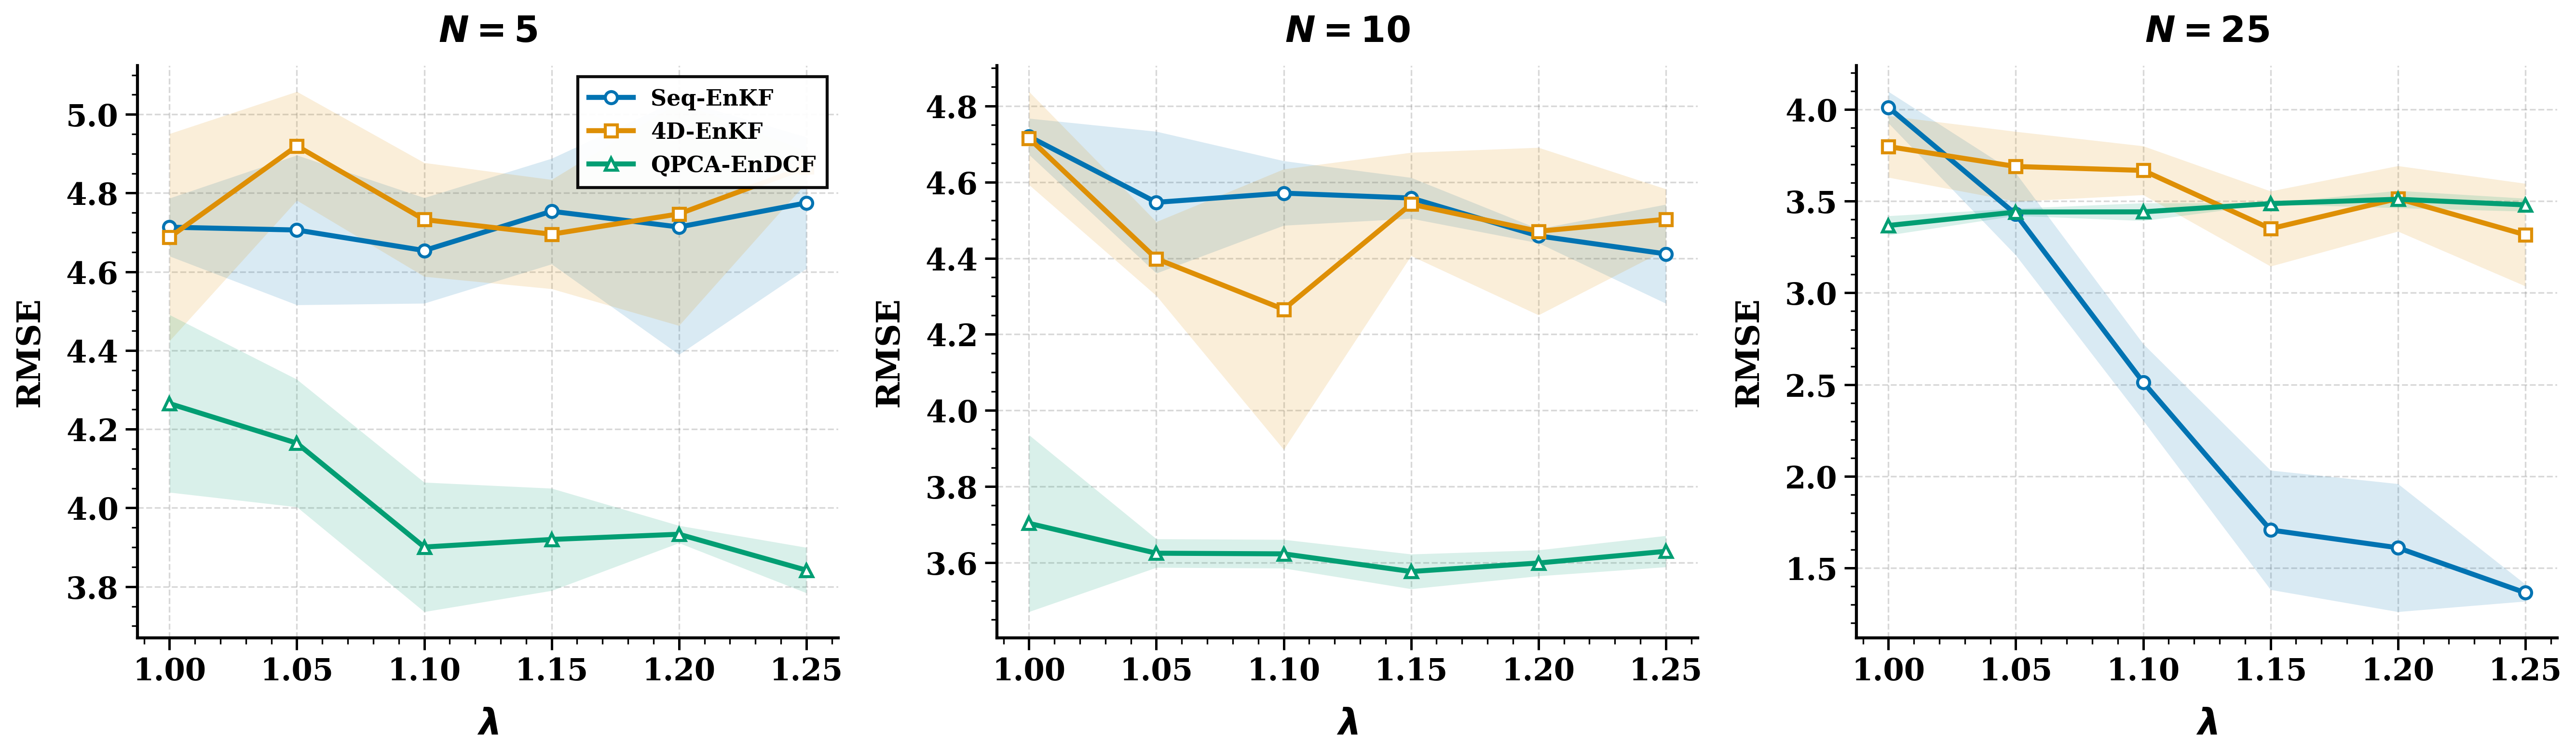

In [17]:
# Load stats back (for verification)
filename1 = "multiplicative_inflation_stats.pkl"

with open(filename1, "rb") as f:
    loaded_stats = pickle.load(f)
# Create the figure
make_multiplicative_inflation_figure(
    loaded_stats, ENSEMBLE_SIZES, MULT_INFLATION_FACTORS, PAPERUQ_FIGURES_DIR
)

In [ ]:
# ============================================================================
# ADDITIVE INFLATION FIGURE
# ============================================================================


def make_additive_inflation_figure(
    add_stats, ENSEMBLE_SIZES, ADD_INFLATION_LEVELS, output_dir
):
    """
    Create publication-quality figure for additive inflation study.

    Parameters
    ----------
    add_stats : dict
        Statistics dictionary with RMSE means and stds
    ENSEMBLE_SIZES : list
        List of ensemble sizes tested
    ADD_INFLATION_LEVELS : list
        List of inflation levels tested
    output_dir : str or Path
        Directory to save figure
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    for idx, (ax, N_ens) in enumerate(zip(axes, ENSEMBLE_SIZES)):
        for key in ["seq", "enkf4d", "qpca4d"]:
            means = np.array(
                [
                    add_stats[key][N_ens][infl]["rmse_mean"]
                    for infl in ADD_INFLATION_LEVELS
                ],
                dtype=float,
            )
            stds = np.array(
                [
                    add_stats[key][N_ens][infl]["rmse_std"]
                    for infl in ADD_INFLATION_LEVELS
                ],
                dtype=float,
            )

            # Plot line with error band
            line = ax.plot(
                ADD_INFLATION_LEVELS,
                means,
                color=CB_COLORS[key],
                label=LABELS[key],
                linewidth=2.5,
                zorder=3,
                **STYLES[key],
            )[0]

            # Shaded error region
            ax.fill_between(
                ADD_INFLATION_LEVELS,
                means - stds,
                means + stds,
                alpha=0.15,
                color=CB_COLORS[key],
                linewidth=0,
                zorder=1,
            )

        # Formatting
        ax.set_xlabel(r"$\alpha$", fontweight="bold", fontsize=18)
        ax.set_ylabel("RMSE", fontweight="bold", fontsize=16)
        ax.set_title(rf"$N={N_ens}$", pad=12, fontsize=18, fontweight="bold")

        # Grid styling
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8, color="gray", zorder=0)
        ax.set_axisbelow(True)

        # Tick formatting

        ax.set_xticks(ADD_INFLATION_LEVELS[1:])  # Skip 0 for ticks
        # Determine precision based on scale
        # decimals = 2 if np.max(ADD_INFLATION_LEVELS) >= 0.5 else 2
        # decimals = 2
        ax.set_xticklabels(["0.01", "0.05", "0.10", "0.15", "0.20"], fontweight="bold")

        # Make ALL tick labels bold using tick_params
        ax.tick_params(axis="both", which="major", labelsize=15)
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")

        # Spine styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor("black")

        # Set margins
        ax.margins(x=0.05)

        # Add legend only to first subplot
        if idx == 0:
            legend = ax.legend(
                loc="upper right",
                frameon=True,
                framealpha=0.95,
                edgecolor="black",
                fancybox=False,
                shadow=False,
            )
            legend.get_frame().set_linewidth(1.5)
            for text in legend.get_texts():
                text.set_fontweight("bold")

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    # Create output directory
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save figure
    output_path = output_dir / "fig_inflation_additive.png"
    plt.savefig(
        output_path, dpi=600, bbox_inches="tight", facecolor="white", edgecolor="none"
    )
    plt.show()
    plt.close(fig)

    print(f"✓ Additive inflation figure saved to: {output_path}")

In [13]:
import os

filename2 = "additive_inflation_stats.pkl"

if os.path.exists(filename2):
    print(f"⚠ File already exists: {filename2} (overwriting...)")
else:
    print(f"Creating new file: {filename2}")

with open(filename2, "wb") as f:
    pickle.dump(add_stats, f)

print(f"✓ Saved: {filename2}")

Creating new file: additive_inflation_stats.pkl
✓ Saved: additive_inflation_stats.pkl


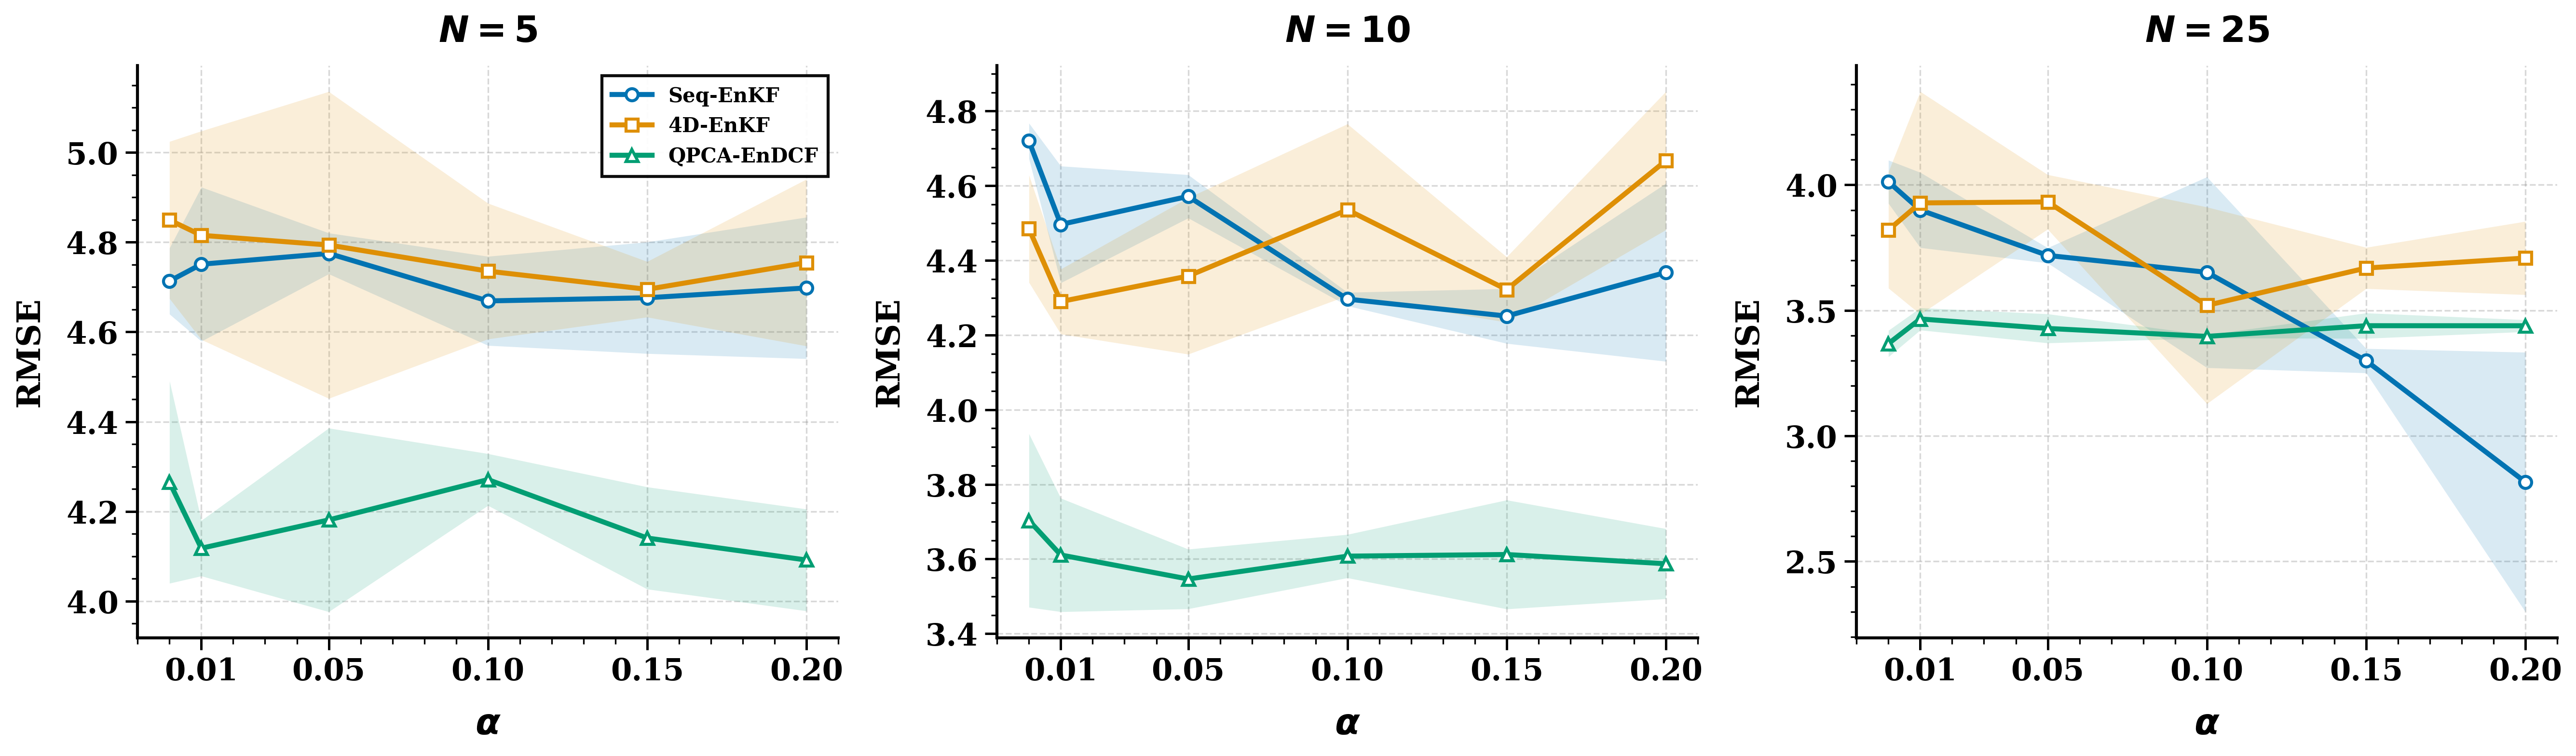

✓ Additive inflation figure saved to: /Users/rylanspence/Desktop/Git/DC/Thesis/QPCA-EnDCF/uq_paper_extractions/figures/fig_inflation_additive.png


In [45]:
filename3 = "additive_inflation_stats.pkl"

with open(filename3, "rb") as f:
    loaded_stats2 = pickle.load(f)

make_additive_inflation_figure(
    loaded_stats2, ENSEMBLE_SIZES, ADD_INFLATION_LEVELS, PAPERUQ_FIGURES_DIR
)

## Summary and Conclusions

### Main Findings

1. **QPCA-EnDCF remains inflation-free across ensemble sizes.** For $N=5,10,20$ the optimal setting is always $\lambda=1.0$ and $\alpha=0.0$, yielding RMSEs of $1.68\pm0.12$, $1.23\pm0.05$, and $1.08\pm0.04$ respectively. Any extra inflation slightly degrades accuracy, confirming that spectral truncation already supplies the required spread control.
2. **Stochastic EnKFs need moderate multiplicative inflation.** Seq-EnKF and 4D-EnKF minimize RMSE near $\lambda=1.10$ for $N\le 10$ and $\lambda=1.05$ for $N=20$, e.g., Seq-EnKF improves from $1.52$ with additive inflation ($\alpha=0.05$) to $1.42$ with multiplicative inflation at $N=10$. Without these factors both filters drift toward under-dispersed ensembles.
3. **Additive inflation is consistently weaker.** Even at their best ($\alpha=0.05$ for $N\le10$ and $\alpha=0.01$ for $N=20$) stochastic EnKF RMSEs stay 5--10\% above the multiplicatively inflated runs, and QPCA-EnDCF always prefers $\alpha=0$. This aligns with the figures showing flatter or degraded curves for additive noise.
4. **QPCA-EnDCF retains a performance margin.** Despite tuning Seq-EnKF and 4D-EnKF, QPCA-EnDCF maintains a 13--22\% lower RMSE at every ensemble size, underscoring the benefit of deterministic residual filtering over perturbed-observation schemes.

### Implications for Paper

- Report the practical guideline that stochastic EnKFs need $\lambda \approx 1.05$--$1.10$ (with small ensembles requiring stronger inflation) while QPCA-EnDCF can be run without any inflation.
- Highlight that multiplicative inflation should be the default for EnKF-style filters, since additive noise never matches its performance in these experiments.
- Emphasize that Figures~
  ef{fig:mult_inflation}--
  ef{fig:add_inflation} and Table~
  ef{tab:optimal_inflation} jointly show QPCA-EnDCF outperforming even optimally tuned stochastic filters.

### Next Steps

1. Explore adaptive multiplicative inflation for stochastic EnKFs to reduce their sensitivity to manually tuned $\lambda$ when ensemble size varies.
2. Test whether QPCA-EnDCF still avoids inflation when the number of retained PCA modes $\kappa$ or the assimilation window length changes.
3. Combine multiplicative inflation with localization or hybrid inflation (multiplicative + additive) to see if the EnKF gap to QPCA-EnDCF can be narrowed for $N=5$.
4. Extend the study to larger ensembles ($N>20$) to confirm whether the required $\lambda$ continues to relax toward 1.0 as sampling error diminishes.
